In [1]:
import pandas as pd
import pypsa

In [2]:
network = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

network.set_snapshots(hours_in_2015.values)

network.add("Bus",
            "electricity bus")

network.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 14:00:00', '2015-12-31 15:00:00',
               '2015-12-31 16:00:00', '2015-12-31 17:00:00',
               '2015-12-31 18:00:00', '2015-12-31 19:00:00',
               '2015-12-31 20:00:00', '2015-12-31 21:00:00',
               '2015-12-31 22:00:00', '2015-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

In [3]:
# load electricity demand data
df_elec = pd.read_csv('data/electricity_demand.csv', sep=';', index_col=0) # in MWh
df_elec.index = pd.to_datetime(df_elec.index) #change index to datatime
country='SWE'
print(df_elec[country].head())

utc_time
2015-01-01 00:00:00+00:00    14845.0
2015-01-01 01:00:00+00:00    14554.0
2015-01-01 02:00:00+00:00    14267.0
2015-01-01 03:00:00+00:00    14224.0
2015-01-01 04:00:00+00:00    14370.0
Name: SWE, dtype: float64


In [4]:
#network.set_snapshots(df_elec.index)
#network.snapshots

In [5]:
# add load to the bus
network.add("Load",
            "load",
            bus="electricity bus",
            p_set=df_elec[country].values)

In [6]:
network.loads_t.p_set 

name,load
snapshot,
2015-01-01 00:00:00,14845.0
2015-01-01 01:00:00,14554.0
2015-01-01 02:00:00,14267.0
2015-01-01 03:00:00,14224.0
2015-01-01 04:00:00,14370.0
...,...
2015-12-31 19:00:00,17548.0
2015-12-31 20:00:00,16973.0
2015-12-31 21:00:00,16469.0


In [7]:
def annuity(n,r):
    """ Calculate the annuity factor for an asset with lifetime n years and
    discount rate  r """

    if r > 0:
        return r/(1. - 1./(1.+r)**n)
    else:
        return 1/n

In [8]:
# We add the different carries: nuclear, gas, solar and wind

network.add("Carrier", "onshorewind")
network.add("Carrier", "offshorewind")
network.add("Carrier", "solar")
network.add("Carrier", "nuclear")
network.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
country = 'SWE'

# add onshore wind generator
df_onshorewind = pd.read_csv('data/CF_onshore_wind_1979-2017.csv', sep=';', index_col=0)
df_onshorewind.index = pd.to_datetime(df_onshorewind.index)
CF_wind = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
capital_cost_onshorewind = annuity(30,0.07)*910000*(1+0.033) # in €/MW
network.add("Generator",
            "onshorewind",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="onshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_onshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind.values)


# add offshore wind generator
df_offshorewind = pd.read_csv('data/CF_offshore_wind_1979-2017.csv', sep=';', index_col=0)
df_offshorewind.index = pd.to_datetime(df_offshorewind.index)
CF_offwind = df_offshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
'''
the overnight cost, lifetime, opex is changed based on reference table 2
'''
capital_cost_offshorewind = annuity(25,0.07)*2506000*(1+0.03) # in €/MW
network.add("Generator",
            "offshorewind",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="offshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_offshorewind,
            marginal_cost = 0,
            p_max_pu = CF_offwind.values)


# add solar PV generator
df_solar = pd.read_csv('data/CF_pv_optimal.csv', sep=';', index_col=0)
df_solar.index = pd.to_datetime(df_solar.index)
CF_solar = df_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
capital_cost_solar = annuity(25,0.07)*425000*(1+0.03) # in €/MW
network.add("Generator",
            "solar",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="solar",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_solar,
            marginal_cost = 0,
            p_max_pu = CF_solar.values)


# add nuclear generator
life_nuclear = 60                    # years
cap_nuclear = 6000000               # €/MW_el
fom_nuclear = 0.025                 # 2.5%/year
capital_cost_nuclear = annuity(life_nuclear, 0.07) * cap_nuclear * (1 + fom_nuclear)

marginal_cost_nuclear = 10.0        # €/MWh_el (example stylized value)

network.add("Generator",
            "nuclear",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="nuclear",
            capital_cost=capital_cost_nuclear,
            marginal_cost=marginal_cost_nuclear)


# add OCGT (Open Cycle Gas Turbine) generator
capital_cost_OCGT = annuity(25,0.07)*560000*(1+0.033) # in €/MW
fuel_cost = 21.6 # in €/MWh_th
efficiency = 0.39 # MWh_elec/MWh_th
marginal_cost_OCGT = fuel_cost/efficiency # in €/MWh_el
network.add("Generator",
            "OCGT",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="gas",
            #p_nom_max=1000,
            capital_cost = capital_cost_OCGT,
            marginal_cost = marginal_cost_OCGT)

#Save the network to a NetCDF file
network.export_to_netcdf("sweden_base_model.nc")


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'sweden_base_model.nc contains: buses, loads, generators, carriers


<xarray.Dataset> Size: 631kB
Dimensions:                      (snapshots: 8760, buses_i: 1, loads_i: 1,
                                  loads_t_p_set_i: 1, generators_i: 5,
                                  generators_t_p_max_pu_i: 3, carriers_i: 5)
Coordinates:
  * snapshots                    (snapshots) int64 70kB 0 1 2 ... 8757 8758 8759
  * buses_i                      (buses_i) object 8B 'electricity bus'
  * loads_i                      (loads_i) object 8B 'load'
  * loads_t_p_set_i              (loads_t_p_set_i) object 8B 'load'
  * generators_i                 (generators_i) object 40B 'onshorewind' ... ...
  * generators_t_p_max_pu_i      (generators_t_p_max_pu_i) object 24B 'onshor...
  * carriers_i                   (carriers_i) object 40B 'onshorewind' ... 'gas'
Data variables: (12/13)
    snapshots_snapshot           (snapshots) datetime64[ns] 70kB 2015-01-01 ....
    snapshots_objective          (snapshots) float64 70kB 1.0 1.0 ... 1.0 1.0
    snapshots_stores             (snapshots) float64 70kB 1.0 1.0 ... 1.0 1.0
    snapshots_generators         (snapshots) float64 70kB 1.0 1.0 ... 1.0 1.0
    loads_bus                    (loads_i) object 8B 'electricity bus'
    loads_t_p_set                (snapshots, loads_t_p_set_i) float64 70kB 1....
    ...                           ...
    generators_p_nom_extendable  (generators_i) bool 5B True True True True True
    generators_carrier           (generators_i) object 40B 'onshorewind' ... ...
    generators_marginal_cost     (generators_i) float64 40B 0.0 0.0 ... 55.38
    generators_capital_cost      (generators_i) float64 40B 7.575e+04 ... 4.9...
    generators_t_p_max_pu        (snapshots, generators_t_p_max_pu_i) float64 210kB ...
    carriers_co2_emissions       (carriers_i) float64 40B 0.0 0.0 0.0 0.0 0.19
Attributes:
    network__multi_invest:  0
    network_name:           Unnamed Network
    network_pypsa_version:  1.1.2
    network_srid:           4326
    crs:                    {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"World Geo...
    meta:                   {}

In [9]:
network.generators_t.p_max_pu

name,onshorewind,offshorewind,solar
snapshot,,,
2015-01-01 00:00:00,0.376,0.668,0.0
2015-01-01 01:00:00,0.376,0.698,0.0
2015-01-01 02:00:00,0.377,0.718,0.0
2015-01-01 03:00:00,0.386,0.714,0.0
2015-01-01 04:00:00,0.396,0.713,0.0
...,...,...,...
2015-12-31 19:00:00,0.282,0.401,0.0
2015-12-31 20:00:00,0.261,0.341,0.0
2015-12-31 21:00:00,0.244,0.333,0.0


In [10]:
network.optimize(solver_name='gurobi')

/var/folders/2y/dv62qx3149n1hrnc89_wzcxm0000gn/T/ipykernel_7224/3854944838.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name='gurobi')
Index(['electricity bus'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 563.86it/s]
INFO:linopy.io: Writing time: 0.15s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2778580


INFO:gurobipy:Set parameter LicenseID to value 2778580


...

Solved in 15720 iterations and 1.03 seconds (1.21 work units)


INFO:gurobipy:Solved in 15720 iterations and 1.03 seconds (1.21 work units)


Optimal objective  7.647689121e+09


INFO:gurobipy:Optimal objective  7.647689121e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43805 primals, 96365 duals
Objective: 7.65e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [11]:
#Total Annualized System Cost in 10^6 €
print(network.objective/1000000) 

7647.6891208725065


In [12]:
#The cost per MWh electricity (LCOE)
print(network.objective/network.loads_t.p.sum()) # EUR/MWh

name
load    56.263461
dtype: float64


In [13]:
#optimal capacity for generators
network.generators.p_nom_opt # in MW

name
onshorewind     37648.230088
offshorewind        0.000000
solar            6334.374150
nuclear             0.000000
OCGT            22373.146018
Name: p_nom_opt, dtype: float64

In [14]:
print(f"cost for onshore wind: {capital_cost_onshorewind:,.2f} €/MW")
print(f"cost for offshore wind: {capital_cost_offshorewind:,.2f} €/MW")
print(f"cost for solar: {capital_cost_solar:,.2f} €/MW")  
print(f"cost for nuclear: {capital_cost_nuclear:,.2f} €/MW")
print(f"cost for OCGT: {capital_cost_OCGT:,.2f} €/MW")

cost for onshore wind: 75,753.64 €/MW
cost for offshore wind: 221,492.39 €/MW
cost for solar: 37,563.55 €/MW
cost for nuclear: 438,059.74 €/MW
cost for OCGT: 49,639.67 €/MW


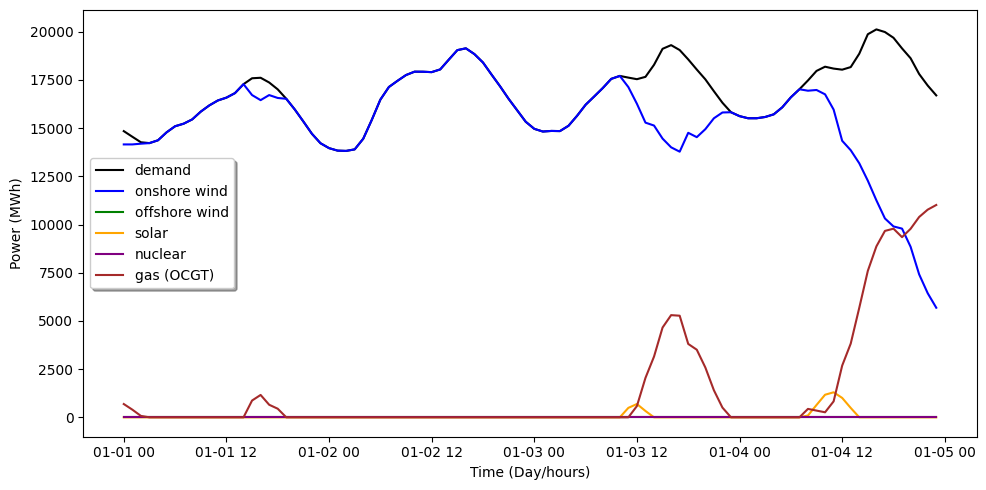

In [15]:
import matplotlib.pyplot as plt
# Plot the generation and demand profiles for the first 4 days in January (96 hours)

plt.figure(figsize=(10, 5))
plt.plot(network.loads_t.p['load'][0:96], color='black', label='demand')
plt.plot(network.generators_t.p['onshorewind'][0:96], color='blue', label='onshore wind')
plt.plot(network.generators_t.p['offshorewind'][0:96], color='green', label='offshore wind')
plt.plot(network.generators_t.p['solar'][0:96], color='orange', label='solar')
plt.plot(network.generators_t.p['nuclear'][0:96], color='purple', label='nuclear')
plt.plot(network.generators_t.p['OCGT'][0:96], color='brown', label='gas (OCGT)')
plt.xlabel('Time (Day/hours)')
plt.ylabel('Power (MWh)')
plt.legend(fancybox=True, shadow=True, loc='best')
plt.tight_layout()

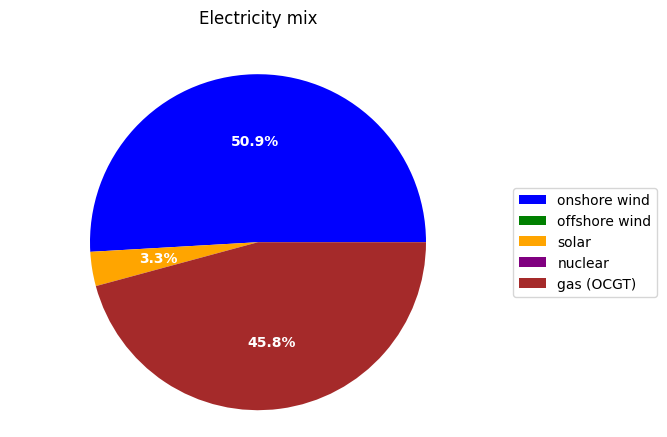

In [16]:
labels = ['onshore wind',
          'offshore wind',
          'solar',
          'nuclear',    
          'gas (OCGT)']
sizes = [network.generators_t.p['onshorewind'].sum(),
         network.generators_t.p['offshorewind'].sum(),
         network.generators_t.p['solar'].sum(),
         network.generators_t.p['nuclear'].sum(),
         network.generators_t.p['OCGT'].sum()]
colors = ['blue', 'green', 'orange', 'purple', 'brown']

def my_autopct(pct):
    # Only show the text if the percentage is greater than 0%
    return f'{pct:.1f}%' if pct > 0 else ''
        
patches, texts, autotexts = plt.pie(
    sizes,
    colors=colors,
    autopct=my_autopct,        
    textprops={'color': 'white', 'weight': 'bold'}, # Makes text white and bold
    wedgeprops={'linewidth': 0}
)

plt.axis('equal')
plt.title('Electricity mix', y=1.07)
plt.legend(patches, labels, loc="center left", bbox_to_anchor=(1, 0.5))

In [17]:
'''This is part 2 of the project, we can fix problem later'''

# co2_limit=1000000 #tonCO2
# network.add("GlobalConstraint",
#             "co2_limit",
#             type="primary_energy",
#             carrier_attribute="co2_emissions",
#             sense="<=",
#             constant=co2_limit)
# network.optimize(solver_name='gurobi')


# network.generators.p_nom_opt #in MW

# #plot the generation and demand profiles for the first 4 days in January (96 hours)
# plt.plot(network.loads_t.p['load'][0:96], color='black', label='demand')
# plt.plot(network.generators_t.p['onshorewind'][0:96], color='blue', label='onshore wind')
# plt.plot(network.generators_t.p['offshorewind'][0:96], color='green', label='offshore wind')
# plt.plot(network.generators_t.p['solar'][0:96], color='orange', label='solar')
# plt.plot(network.generators_t.p['nuclear'][0:96], color='purple', label='nuclear')
# plt.plot(network.generators_t.p['OCGT'][0:96], color='brown', label='gas (OCGT)')
# plt.legend(fancybox=True, shadow=True, loc='best')

# #plot the generation mix 
# labels = ['onshore wind', 'offshore wind', 'solar', 'nuclear', 'gas (OCGT)' ]
# sizes = [network.generators_t.p['onshorewind'].sum(),
#          network.generators_t.p['offshorewind'].sum(),
#          network.generators_t.p['solar'].sum(),
#          network.generators_t.p['nuclear'].sum(),
#          network.generators_t.p['OCGT'].sum()]

# colors = ['blue', 'green', 'orange', 'purple', 'brown']

# plt.pie(sizes,
#         colors=colors,
#         labels=labels,
#         wedgeprops={'linewidth':0})
# plt.axis('equal')

# plt.title('Electricity mix', y=1.07)


'This is part 2 of the project, we can fix problem later'

## Part A

choose a different country/region/city/system and calculate the optimal capacities for renewable and non-renewable generators. You can add as many technologies as you want. Remember to provide a reference for the cost assumptions. Plot the dispatch time series for a week in summer and winter. Plot the annual electricity mix. Use the duration curves or the capacity factor to investigate the contribution of different technologies.

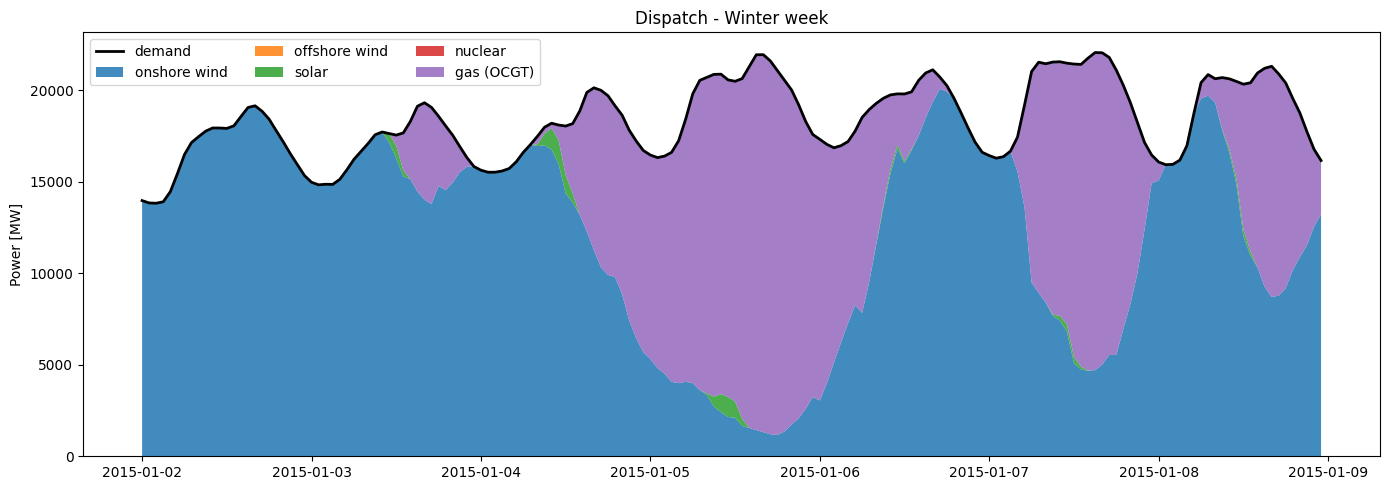

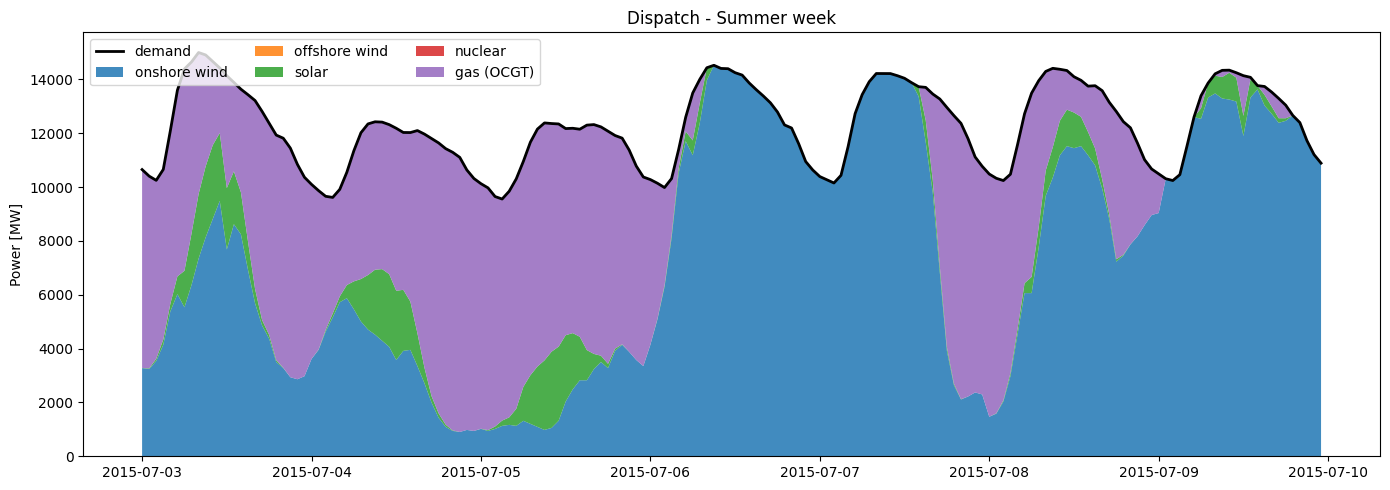

In [18]:
# Winter week and summer week 
import matplotlib.pyplot as plt

def plot_dispatch_week(network, start_date, end_date, title):
    dispatch = network.generators_t.p.loc[start_date:end_date, ["onshorewind", "offshorewind", "solar", "nuclear", "OCGT"]]
    demand = network.loads_t.p.loc[start_date:end_date, "load"]

    plt.figure(figsize=(14, 5))
    plt.plot(demand.index, demand, color="black", linewidth=2, label="demand")
    plt.stackplot(dispatch.index,
                  dispatch["onshorewind"],
                  dispatch["offshorewind"],
                  dispatch["solar"],
                  dispatch["nuclear"],
                  dispatch["OCGT"],
                  labels=["onshore wind", "offshore wind", "solar", "nuclear", "gas (OCGT)"],
                  alpha=0.85)
    plt.title(title)
    plt.ylabel("Power [MW]")
    plt.legend(loc="upper left", ncol=3)
    plt.tight_layout()
    plt.show()

plot_dispatch_week(network,
                   "2015-01-02 00:00:00",
                   "2015-01-08 23:00:00",
                   "Dispatch - Winter week")

plot_dispatch_week(network,
                   "2015-07-03 00:00:00",
                   "2015-07-09 23:00:00",
                   "Dispatch - Summer week")

Annual generation by technology (MWh):
name
onshorewind     69206464.0
OCGT            62240418.0
solar            4479508.0
offshorewind           0.0
nuclear                0.0
dtype: float64


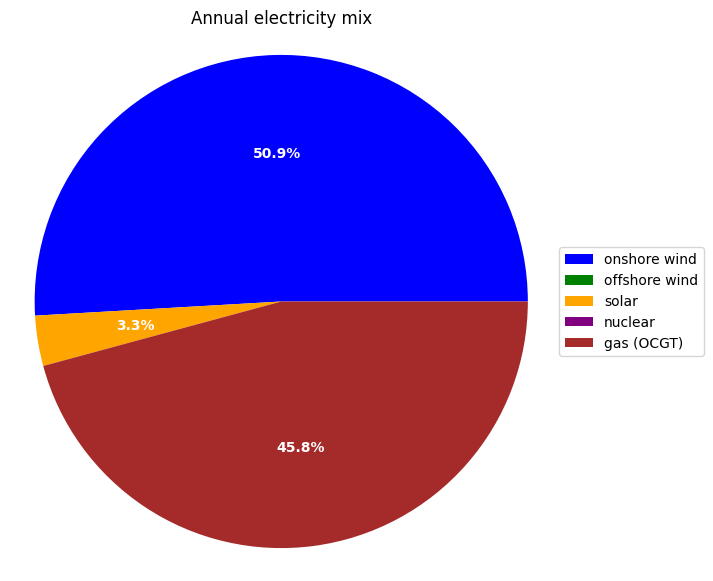

In [19]:
# Annual energy mix 
annual_generation = network.generators_t.p.sum().sort_values(ascending=False)
print("Annual generation by technology (MWh):")
print(annual_generation.round(0))

labels = ["onshore wind", "offshore wind", "solar", "nuclear", "gas (OCGT)"]
sizes = [
    network.generators_t.p["onshorewind"].sum(),
    network.generators_t.p["offshorewind"].sum(),
    network.generators_t.p["solar"].sum(),
    network.generators_t.p["nuclear"].sum(),
    network.generators_t.p["OCGT"].sum()
]

colors = ['blue', 'green', 'orange', 'purple', 'brown']

plt.figure(figsize=(7, 7))
patches, texts, autotexts = plt.pie(sizes,
        colors=colors,
        autopct=my_autopct,        
        textprops={'color': 'white', 'weight': 'bold'},
        wedgeprops={"linewidth": 0})

plt.axis("equal")
plt.title("Annual electricity mix")
plt.legend(patches, labels, loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

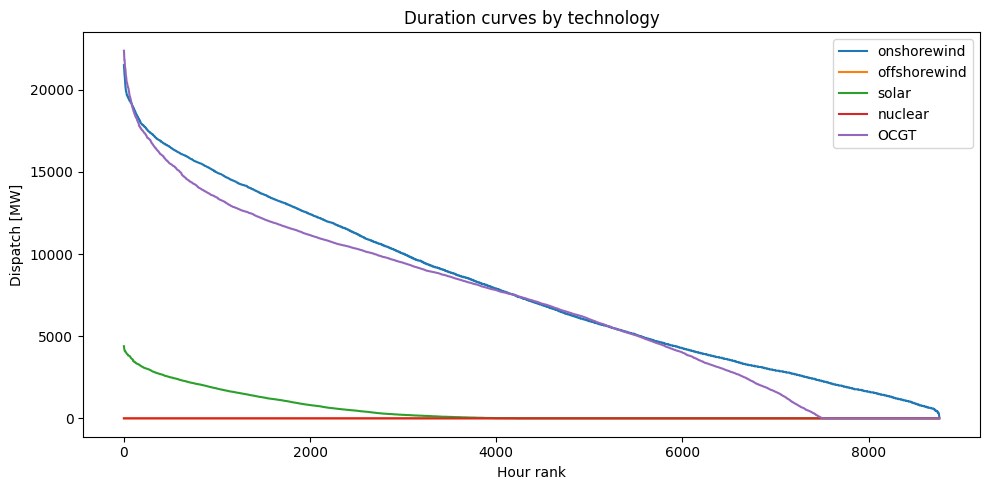

In [20]:
# Duration curves
plt.figure(figsize=(10, 5))

for tech in ["onshorewind", "offshorewind", "solar", "nuclear", "OCGT"]:
    sorted_dispatch = network.generators_t.p[tech].sort_values(ascending=False).reset_index(drop=True)
    plt.plot(sorted_dispatch, label=tech)

plt.xlabel("Hour rank")
plt.ylabel("Dispatch [MW]")
plt.title("Duration curves by technology")
plt.legend()
plt.tight_layout()
plt.show()

## Part B

Investigate how sensitive your results are to the interannual variability of solar and wind generation. Plot the average capacity and variability obtained for every generator using different weather years.

In [21]:
# weather_years = range(2000, 2018)   # only adding 18 years cause if not it's too slow :(
# results = []

# # keep 2017 demand for all runs to isolate weather sensitivity
# load_2017 = df_elec["Actual Total Load (MW)"].values

# for year in weather_years:
#     print(f"Running weather year {year}...")

#     # 1. Create snapshots for this weather year
#     new_snapshots = pd.date_range(f"{year}-01-01 00:00", f"{year}-12-31 23:00", freq="h")
#     network.set_snapshots(new_snapshots)

#     # 2. Extract renewable profiles for this exact year
#     onshore_year = df_onshorewind[country][df_onshorewind.index.year == year]
#     offshore_year = df_offshorewind[country][df_offshorewind.index.year == year]
#     solar_year = df_solar[country][df_solar.index.year == year]

#     # 3. Make sure lengths match
#     if not (len(onshore_year) == len(new_snapshots) == len(offshore_year) == len(solar_year)):
#         print(f"Skipping {year}: mismatch in time series length")
#         continue

#     # 4. Update renewable availability
#     network.generators_t.p_max_pu.loc[:, "onshorewind"] = onshore_year.values
#     network.generators_t.p_max_pu.loc[:, "offshorewind"] = offshore_year.values
#     network.generators_t.p_max_pu.loc[:, "solar"] = solar_year.values

#     # 5. Update load
#     if len(load_2017) == len(new_snapshots):
#         network.loads_t.p_set.loc[:, "load"] = load_2017
#     else:
#         print(f"Skipping {year}: load length mismatch")
#         continue

#     # 6. Optimize
#     network.optimize(solver_name="gurobi")

#     # 7. Store capacities
#     opt_caps = network.generators.p_nom_opt.copy()
#     opt_caps["year"] = year
#     results.append(opt_caps)

# # 8. Collect all results
# df_sensitivity = pd.DataFrame(results).set_index("year")

# print(df_sensitivity)

## Part C

Add some storage technology/ies and investigate how they behave and what their impact is on the
optimal system configuration.

In [22]:
network

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1
 - Carrier: 5
 - Generator: 5
 - Load: 1
 - SubNetwork: 1
Snapshots: 8760

In [23]:
# Storage Costs
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

In [ ]:
# --- Storage Units Cost Calculation 1---

capital_cost_storage_1=annuity(10, 0.07) * costs.at["battery inverter", "investment"] + 2 * annuity(25, 0.07) * costs.at["battery storage", "investment"]
capital_cost_storage_1                                                                # ^ this is 2 hours of storage

np.float64(49895.78185594785)

In [25]:
# --- Storage Units Cost Calculation 2---
hours = 6
capital_cost_storage_2 = annuity(25, 0.07) * 189.861 * 1000 * hours
+ annuity(10, 0.07) * 213.9279 * 1000 # in €/MW

# battery Inverter: 213.9279 €/kW
# battery Inverter: 10 years
# battery storage: 189.861 €/kWh
# battery storage: 25 years

capital_cost_storage_2

97752.42366019674

In [ ]:
# --- Storage Units Cost Calculation 3---

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

capital_cost_storage_3=costs.at["battery inverter", "capital_cost"] + 2 *costs.at["battery storage", "capital_cost"]
capital_cost_storage_3

np.float64(47801083.98779313)

In [ ]:
# We add another carrier: battery storage

network.add("Carrier", "battery", co2_emissions=0)

# --- Storage Units ---
network.add(
   "StorageUnit",
   "SE storage",
   bus="electricity bus",
   carrier="battery",
   p_nom=0,
   #max_hours=6, # fixed ratio of energy capacity to power capacity: 6 hours of storage at full power
   #capital_cost=capital_cost_storage,
   #marginal_cost=0,
   #p_nom_extendable=True,
   #p_nom_max=1000,  # maximum capacity can be limited due to environmental constraints

   max_hours=2,
   capital_cost=capital_cost_storage_3,
   efficiency_store=costs.at["battery inverter", "efficiency"],
   efficiency_dispatch=costs.at["battery inverter", "efficiency"],
   p_nom_extendable=True,
   cyclic_state_of_charge=True,
)

In [30]:
network

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1
 - Carrier: 6
 - Generator: 5
 - Load: 1
 - StorageUnit: 1
 - SubNetwork: 1
Snapshots: 8760

In [31]:
network.optimize(solver_name="gurobi") # Solve the optimization problem with the new storage unit
# add this if doesnt work , assign_all_duals=False

/var/folders/2y/dv62qx3149n1hrnc89_wzcxm0000gn/T/ipykernel_7224/1451708396.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name="gurobi") # Solve the optimization problem with the new storage unit
Index(['electricity bus'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 776.79it/s]
INFO:linopy.io: Writing time: 0.18s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2778580


INFO:gurobipy:Set parameter LicenseID to value 2778580


...

Solved in 36392 iterations and 1.95 seconds (2.10 work units)


INFO:gurobipy:Solved in 36392 iterations and 1.95 seconds (2.10 work units)


Optimal objective  7.647689121e+09


INFO:gurobipy:Optimal objective  7.647689121e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 70086 primals, 157686 duals
Objective: 7.65e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

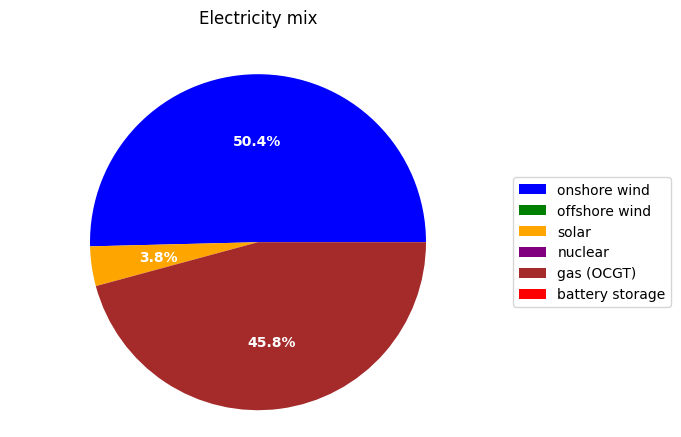

In [32]:
labels = ['onshore wind',
          'offshore wind',
          'solar',
          'nuclear',
          'gas (OCGT)',
          'battery storage']

sizes = [network.generators_t.p['onshorewind'].sum(),
         network.generators_t.p['offshorewind'].sum(),
         network.generators_t.p['solar'].sum(),
         network.generators_t.p['nuclear'].sum(),
         network.generators_t.p['OCGT'].sum(),
         network.storage_units_t.p['SE storage'].clip(lower=0).sum()]

colors = ['blue', 'green', 'orange', 'purple', 'brown', 'red']

def my_autopct(pct):
    return f'{pct:.1f}%' if pct > 0 else ''

patches, texts, autotexts = plt.pie(
    sizes,
    colors=colors,
    autopct=my_autopct,
    textprops={'color': 'white', 'weight': 'bold'},
    wedgeprops={'linewidth': 0}
)

plt.axis('equal')
plt.title('Electricity mix', y=1.07)
plt.legend(patches, labels, loc="center left", bbox_to_anchor=(1, 0.5))